Libraries And Dataset

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
import squarify
from matplotlib import pyplot

In [2]:
# Loading data
df = pd.read_csv("../data/netflix_customer_survey.csv")
print(df.head())

   customerid  NumberAccounts  price ExtraContent           ads  selected
0           7               2     10          HBO   one_per_day         1
1           7               6      8       Marvel  one_per_show         1
2           7               4     15       Disney   one_per_day         1
3           7               5     10          HBO   one_per_day         1
4           7               1     20       Soccer  one_per_show         1


# Data Processing

In [3]:
# Isolate X and Y
y = df["selected"]
X = df.drop(columns=["selected","customerid"])
print(X.head(2))

   NumberAccounts  price ExtraContent           ads
0               2     10          HBO   one_per_day
1               6      8       Marvel  one_per_show


In [4]:
# Create dummy Variables
X_dummy = pd.get_dummies(X, columns=X.columns)
print(X_dummy.head())

   NumberAccounts_1  NumberAccounts_2  NumberAccounts_3  NumberAccounts_4  \
0             False              True             False             False   
1             False             False             False             False   
2             False             False             False              True   
3             False             False             False             False   
4              True             False             False             False   

   NumberAccounts_5  NumberAccounts_6  price_8  price_10  price_12  price_15  \
0             False             False    False      True     False     False   
1             False              True     True     False     False     False   
2             False             False    False     False     False      True   
3              True             False    False      True     False     False   
4             False             False    False     False     False     False   

   ...  price_20  ExtraContent_Disney  ExtraContent_HBO 

Regression Model

In [5]:
model = sm.GLM(y,
               X_dummy,
               family=sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               selected   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2982
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1948.3
Date:                Sun, 06 Sep 2026   Deviance:                       3896.6
Time:                        09:49:18   Pearson chi2:                 3.00e+03
No. Iterations:                   100   Pseudo R-squ. (CS):            0.08371
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
NumberAccounts_1                -0.7036      0.090     -7.778      0.000      -0.881      -0.526
NumberAccounts_2                -0.0733      0.088     -0.831      0.406      -0.246       0.100
NumberAccounts_3                -0.0211      0.088     -0.240      0.810      -0.193       0.151
NumberAccounts_4                 0.1247      0.083      1.494      0.135      -0.039       0.288
NumberAccounts_5                 0.1316      0.084      1.560      0.119      -0.034       0.297
NumberAccounts_6                 0.4963      0.082      6.030      0.000       0.335       0.658
price_8                          0.2964      0.085      3.501      0.000       0.130       0.462
price_10                         0.2204      0.087      2.534      0.011       0.050       0.391
price_12                         0.2015      0.083      2.437      0.015       0.039       0.364
price_15                         0.0203      0.084      0.241      0.810      -0.145       0.186
price_18                        -0.1027      0.087     -1.180      0.238      -0.273       0.068
price_20                        -0.6810      0.090     -7.526      0.000      -0.858      -0.504
ExtraContent_Disney              0.2277      0.087      2.605      0.009       0.056       0.399
ExtraContent_HBO                 0.2264      0.085      2.671      0.008       0.060       0.393
ExtraContent_Marvel              0.1449      0.084      1.722      0.085      -0.020       0.310
ExtraContent_Prime originals     0.1275      0.086      1.476      0.140      -0.042       0.297
ExtraContent_Soccer             -0.2044      0.085     -2.400      0.016      -0.371      -0.038
ExtraContent_less content       -0.5673      0.088     -6.462      0.000      -0.739      -0.395
ads_none                         0.2075      0.055      3.749      0.000       0.099       0.316
ads_one_per_day                  0.1088      0.056      1.932      0.053      -0.002       0.219
ads_one_per_show                -0.3615      0.057     -6.324      0.000      -0.474      -0.249
================================================================================================
"""

Conjoint Analysis

In [6]:
# Create a DF with the results
df_result = pd.DataFrame({"param_name": model.params.keys(),
                          "partworth": model.params.values,
                          "pval": model.pvalues})
df_result


,param_name,partworth,pval
NumberAccounts_1,NumberAccounts_1,-0.703628,7.392448e-15
NumberAccounts_2,NumberAccounts_2,-0.073273,4.061347e-01
NumberAccounts_3,NumberAccounts_3,-0.021075,8.103636e-01
NumberAccounts_4,NumberAccounts_4,0.124729,1.352014e-01
NumberAccounts_5,NumberAccounts_5,0.131611,1.186512e-01
NumberAccounts_6,NumberAccounts_6,0.496329,1.640291e-09
price_8,price_8,0.296356,4.640779e-04
price_10,price_10,0.220355,1.127409e-02
price_12,price_12,0.201456,1.482417e-02
price_15,price_15,0.020285,8.098895e-01


In [7]:
# Sort values
df_result = df_result.sort_values(by = "partworth",
                                  ascending= True)

In [8]:
# Identifying statistically significant variables.
df_result["is_significant"] = (df_result["pval"] < 0.05)
df_result['color'] = ["Blue" if x else "Red" for x in df_result['is_significant']]
df_result.head()

,param_name,partworth,pval,is_significant,color
NumberAccounts_1,NumberAccounts_1,-0.703628,7.392448e-15,True,Blue
price_20,price_20,-0.681035,5.227500e-14,True,Blue
ExtraContent_less content,ExtraContent_less content,-0.567315,1.034701e-10,True,Blue
ads_one_per_show,ads_one_per_show,-0.361521,2.554983e-10,True,Blue
ExtraContent_Soccer,ExtraContent_Soccer,-0.204421,1.638033e-02,True,Blue


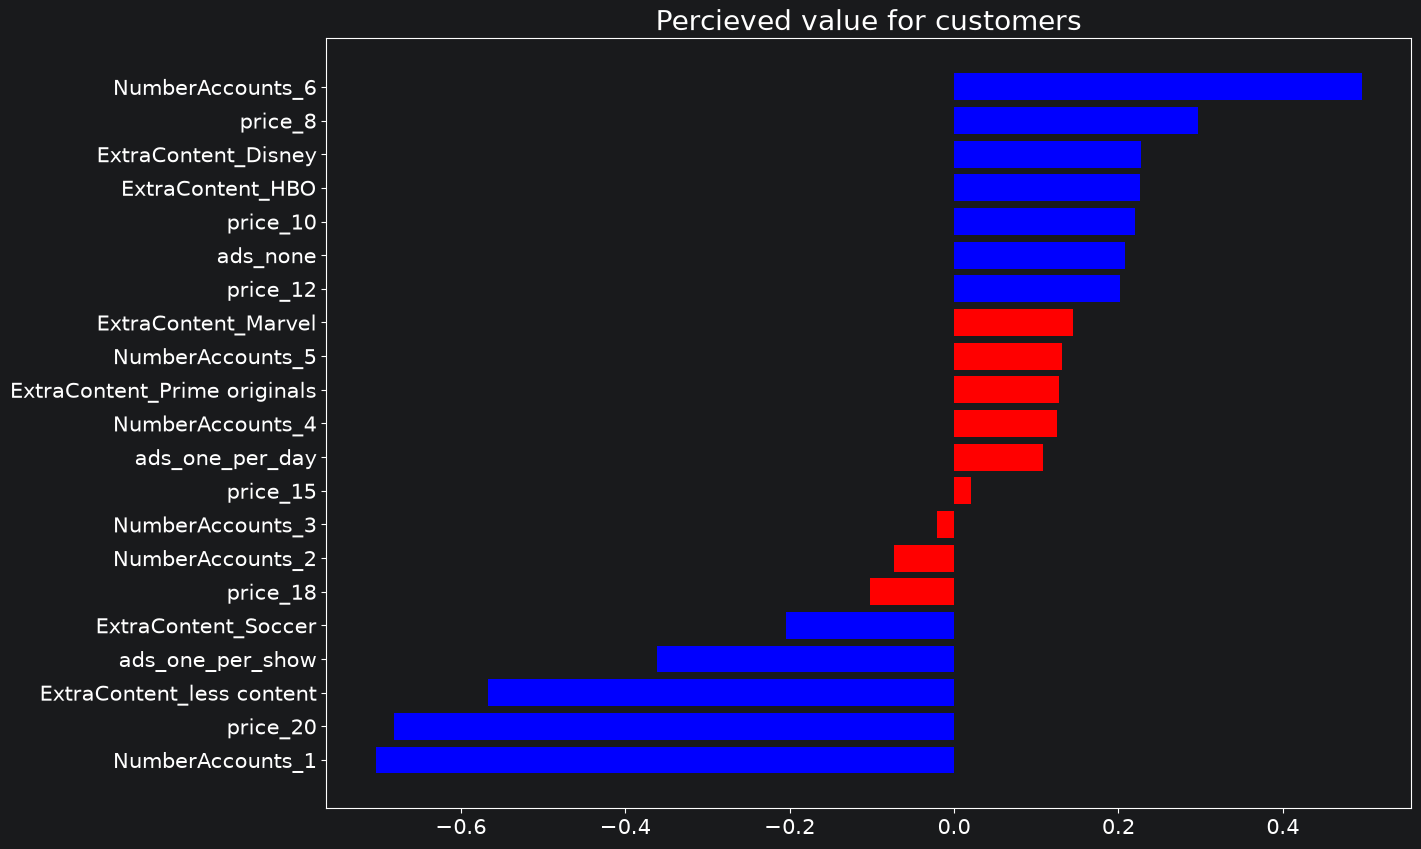

In [9]:
# Plot the partworth
f, ax = plt.subplots(figsize= (14,10))
values = df_result["partworth"]
xbar = np.arange(len(values))

# Bar plot
plt.barh(xbar,
         values,
         color = df_result['color'])
plt.title("Percieved value for customers",
          fontsize= 20)
# Customizing ticks
plt.yticks(xbar,
           labels=df_result['param_name'],
           fontsize = 15)
plt.xticks(fontsize = 15)
plt.show()

Specific groups of features

In [10]:
# Isolate the feature group
feature = "price"
attributes = []
coefficients = []

for i in range(len(df_result)):
    if df_result.iloc[i,0].find(feature) == 0:
        attributes.append(df_result.iloc[i,0])
        coefficients.append(df_result.iloc[i,1])

# print(attributes)
# print(coefficients)

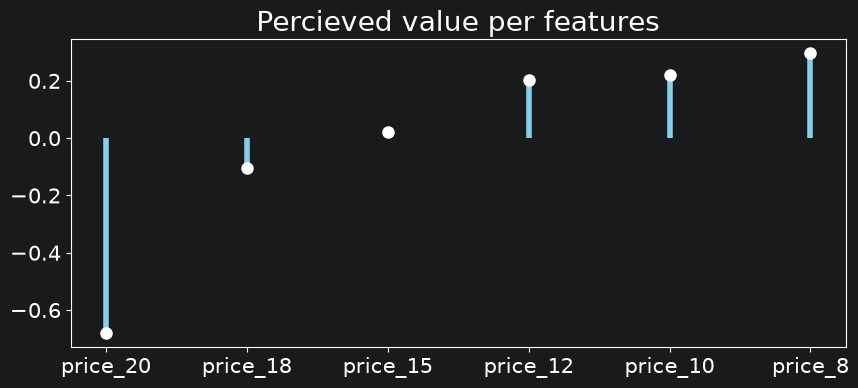

In [11]:
# Plot the partworth
f, ax = plt.subplots(figsize= (10,4))
plt.title("Percieved value per features",
          fontsize= 20)

# Lollipop Chat
(markers,stemlines,baseline) = plt.stem(attributes,
                                        coefficients,
                                        linefmt= "-",
                                        markerfmt= "o",
                                        basefmt=" ")

# Customizing Lollipop
plt.setp(stemlines,
         color = "skyblue",
         linewidth = 4)
plt.setp(markers,
         color = "White",
         markersize = 8 )

#  Customizing ticks
plt.yticks(fontsize = 15)
plt.xticks(fontsize = 15)
plt.show()

# Feature Importance

In [12]:
# Coefficients
features_partworth = {}
for key, coeff in model.params.items():
    split_key = key.split('_')
    feature = split_key[0]
    if feature not in features_partworth:
        features_partworth[feature] = list()
    features_partworth[feature].append(coeff)
features_partworth

{'NumberAccounts': [-0.7036279027287388,
  -0.07327303507180234,
  -0.02107483716919472,
  0.12472946090454715,
  0.13161129368982522,
  0.4963285072203885],
 'price': [0.2963560640915968,
  0.22035450455492003,
  0.20145581157557566,
  0.02028548132789995,
  -0.10272294749582088,
  -0.6810354272091472],
 'ExtraContent': [0.22765488246442436,
  0.2264227310503487,
  0.14487363790648575,
  0.12747775869868622,
  -0.20442075324826658,
  -0.5673147700266535],
 'ads': [0.2074514556617818, 0.10876261844324847, -0.36152058726000524]}

In [13]:
# Calculation : Maximum of feature(price_8) Minus Minimum of a feature(price_20)
importance_per_feature = {k : max(v) - min(v) for k,v in features_partworth.items()}
importance_per_feature

{'NumberAccounts': 1.1999564099491273,
 'price': 0.977391491300744,
 'ExtraContent': 0.7949696524910779,
 'ads': 0.568972042921787}

In [14]:
# Computing the sum of importances
total_importances = sum(importance_per_feature.values())
total_importances

3.541289596662736

In [15]:
# Relative importance (adds up to 100 )
relative_importance_per_feature =  {
    k: round(100 * v/total_importances,1) for k,v in importance_per_feature.items()
}
relative_importance_per_feature

{'NumberAccounts': 33.9, 'price': 27.6, 'ExtraContent': 22.4, 'ads': 16.1}

In [16]:
# Build DF
df_importances = pd.DataFrame(
    list(relative_importance_per_feature.items()),
    columns= ['feature','relative_importance'])
df_importances

,feature,relative_importance
0,NumberAccounts,33.9
1,price,27.6
2,ExtraContent,22.4
3,ads,16.1


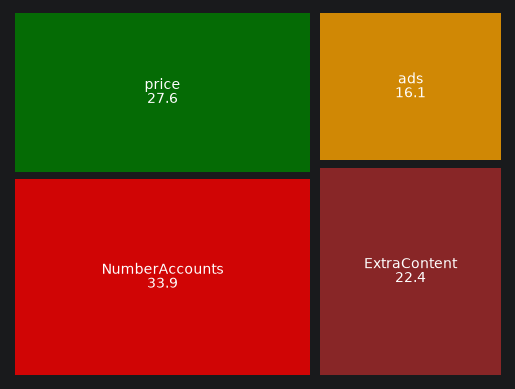

In [17]:
# Treemap
squarify.plot(sizes= df_importances.relative_importance,
              label= df_importances.feature,
              color=['red','green','brown','orange'],
              value= df_importances.relative_importance,
              alpha = 0.8,
              pad=1)
plt.axis('off')
plt.show()

# Interaction Terms

In [18]:
# Create Interaction terms
df['content_ads'] = df.ExtraContent + '_' + df.ads
df.head()

,customerid,NumberAccounts,price,ExtraContent,ads,selected,content_ads
0,7,2,10,HBO,one_per_day,1,HBO_one_per_day
1,7,6,8,Marvel,one_per_show,1,Marvel_one_per_show
2,7,4,15,Disney,one_per_day,1,Disney_one_per_day
3,7,5,10,HBO,one_per_day,1,HBO_one_per_day
4,7,1,20,Soccer,one_per_show,1,Soccer_one_per_show


In [19]:
# Remove the variables in the interaction term
df_interaction = df.drop(columns=['ads','ExtraContent'])
df_interaction.head()

,customerid,NumberAccounts,price,selected,content_ads
0,7,2,10,1,HBO_one_per_day
1,7,6,8,1,Marvel_one_per_show
2,7,4,15,1,Disney_one_per_day
3,7,5,10,1,HBO_one_per_day
4,7,1,20,1,Soccer_one_per_show


# Data Processing Interaction

In [20]:
# Isolate X and Y
y = df_interaction["selected"]
X = df_interaction.drop(columns=["selected","customerid"])
print(X.head(2))

   NumberAccounts  price          content_ads
0               2     10      HBO_one_per_day
1               6      8  Marvel_one_per_show


In [21]:
# Create dummy Variables
X_dummy = pd.get_dummies(X, columns=X.columns)
X_dummy.head()

,NumberAccounts_1,NumberAccounts_2,NumberAccounts_3,NumberAccounts_4,NumberAccounts_5,NumberAccounts_6,price_8,price_10,price_12,price_15,...,content_ads_Marvel_one_per_show,content_ads_Prime originals_none,content_ads_Prime originals_one_per_day,content_ads_Prime originals_one_per_show,content_ads_Soccer_none,content_ads_Soccer_one_per_day,content_ads_Soccer_one_per_show,content_ads_less content_none,content_ads_less content_one_per_day,content_ads_less content_one_per_show
0,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


# Regression Model Interaction

In [22]:
model2 = sm.GLM(y,
               X_dummy,
               family=sm.families.Binomial()).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               selected   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2972
Model Family:                Binomial   Df Model:                           27
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1941.8
Date:                Sun, 06 Sep 2026   Deviance:                       3883.6
Time:                        09:49:23   Pearson chi2:                 3.00e+03
No. Iterations:                   100   Pseudo R-squ. (CS):            0.08767
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
NumberAccounts_1                            -0.7165      0.091     -7.849      0.000      -0.895      -0.538
NumberAccounts_2                            -0.0710      0.090     -0.788      0.430      -0.248       0.106
NumberAccounts_3                            -0.0334      0.089     -0.374      0.708      -0.208       0.142
NumberAccounts_4                             0.1110      0.085      1.305      0.192      -0.056       0.278
NumberAccounts_5                             0.1214      0.086      1.411      0.158      -0.047       0.290
NumberAccounts_6                             0.4918      0.084      5.820      0.000       0.326       0.657
price_8                                      0.2914      0.086      3.370      0.001       0.122       0.461
price_10                                     0.2098      0.090      2.338      0.019       0.034       0.386
price_12                                     0.2002      0.084      2.382      0.017       0.035       0.365
price_15                                     0.0086      0.086      0.100      0.920      -0.160       0.177
price_18                                    -0.1128      0.089     -1.274      0.203      -0.286       0.061
price_20                                    -0.6940      0.091     -7.600      0.000      -0.873      -0.515
content_ads_Disney_none                      0.3338      0.155      2.152      0.031       0.030       0.638
content_ads_Disney_one_per_day               0.5470      0.176      3.114      0.002       0.203       0.891
content_ads_Disney_one_per_show             -0.1554      0.158     -0.983      0.326      -0.465       0.154
content_ads_HBO_none                         0.5291      0.161      3.278      0.001       0.213       0.845
content_ads_HBO_one_per_day                  0.5095      0.157      3.239      0.001       0.201       0.818
content_ads_HBO_one_per_show                -0.3536      0.156     -2.260      0.024      -0.660      -0.047
content_ads_Marvel_none                      0.2568      0.154      1.670      0.095      -0.045       0.558
content_ads_Marvel_one_per_day               0.2297      0.159      1.447      0.148      -0.082       0.541
content_ads_Marvel_one_per_show             -0.0540      0.150     -0.359      0.720      -0.349       0.241
content_ads_Prime originals_none             0.2563      0.159      1.611      0.107      -0.055       0.568
content_ads_Prime originals_one_per_day      0.1288      0.155      0.830      0.406      -0.175       0.433
content_ads_Prime originals_one_per_show     0.0195      0.162      0.120      0.904      -0.298       0.337
content_ads_Soccer_none                      0.1457      0.154      0.944      0.345      -0.157       0.448
content_ads_Soccer_one_per_day 

# Interation term result

In [23]:
# Create a DF with the results
df_result_interaction = pd.DataFrame({"param_name": model2.params.keys(),
                                      "partworth": model2.params.values,
                                      "pval": model2.pvalues}).sort_values(by = 'partworth')
df_result_interaction

,param_name,partworth,pval
content_ads_less content_one_per_show,content_ads_less content_one_per_show,-1.090208,3.749518e-10
NumberAccounts_1,NumberAccounts_1,-0.716549,4.206508e-15
price_20,price_20,-0.693997,2.960010e-14
content_ads_Soccer_one_per_show,content_ads_Soccer_one_per_show,-0.506403,1.497314e-03
content_ads_less content_one_per_day,content_ads_less content_one_per_day,-0.423625,8.330032e-03
content_ads_HBO_one_per_show,content_ads_HBO_one_per_show,-0.353566,2.380441e-02
content_ads_Soccer_one_per_day,content_ads_Soccer_one_per_day,-0.244848,1.126816e-01
content_ads_less content_none,content_ads_less content_none,-0.224970,1.355595e-01
content_ads_Disney_one_per_show,content_ads_Disney_one_per_show,-0.155365,3.255388e-01
price_18,price_18,-0.112797,2.027999e-01


In [24]:
# Isolate the feature group
feature = "content_ads"
attributes = []
coefficients = []

for i in range(len(df_result_interaction)):
    if df_result_interaction.iloc[i,0].find(feature) == 0:
        if df_result_interaction.iloc[i,0].find('none') == -1:
            attributes.append(df_result_interaction.iloc[i,0])
            coefficients.append(df_result_interaction.iloc[i,1])

# print(attributes)
# print(coefficients)

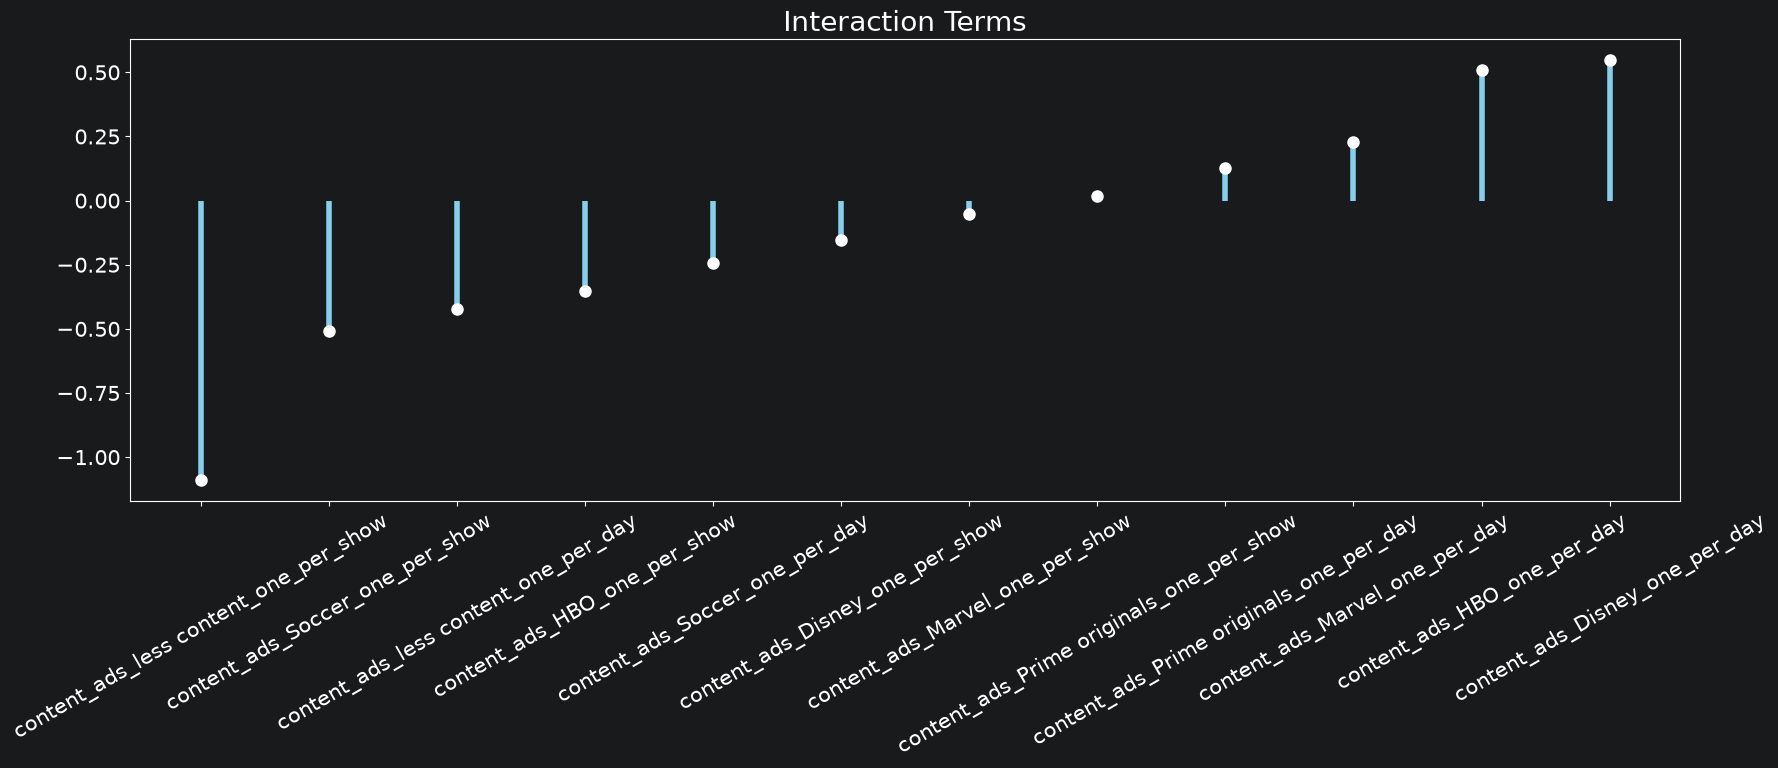

In [26]:
# Plot the partworth
f, ax = plt.subplots(figsize= (20,6))
plt.title("Interaction Terms",
          fontsize= 20)

# Lollipop Chat
(markers,stemlines,baseline) = plt.stem(attributes,
                                        coefficients,
                                        linefmt= "-",
                                        markerfmt= "o",
                                        basefmt=" ")

# Customizing Lollipop
plt.setp(stemlines,
         color = "skyblue",
         linewidth = 4)
plt.setp(markers,
         color = "White",
         markersize = 8 )

#  Customizing ticks
plt.yticks(fontsize = 15)
plt.xticks(fontsize = 15,
           rotation = 30)
plt.show()